# Lets go with Phase 1
exploring the data set

In [1]:
import pandas as pd
from google.colab import files
print("You are ready to go")

You are ready to go


In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
#I see we got no null values! lets go with the questions
#1 How many patients have diabetes versus those who don't?
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


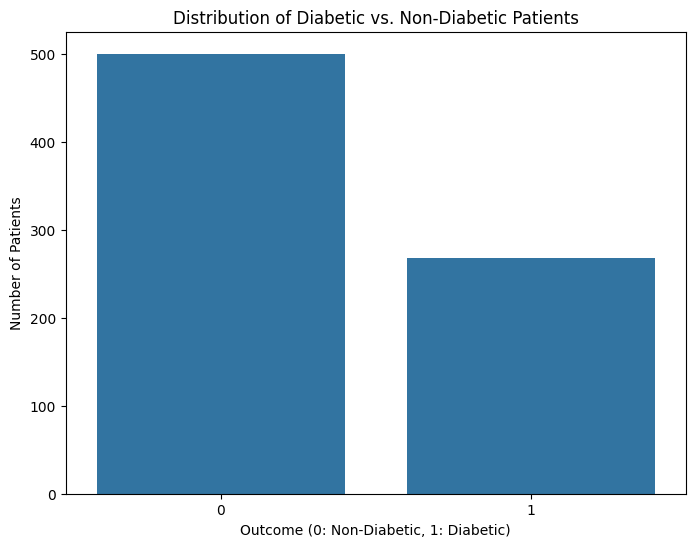

In [6]:
#adding some visuallization
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.countplot(x="Outcome", data=df)
plt.title("Distribution of Diabetic vs. Non-Diabetic Patients")
plt.xlabel("Outcome (0: Non-Diabetic, 1: Diabetic)")
plt.ylabel("Number of Patients")
plt.show()

In [7]:
#2  What's the relationship between glucose levels and the outcome?
#trying to catch any relation between thus 2 columns
avg_glucose = df.groupby('Outcome')['Glucose'].mean()
print(avg_glucose)

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64


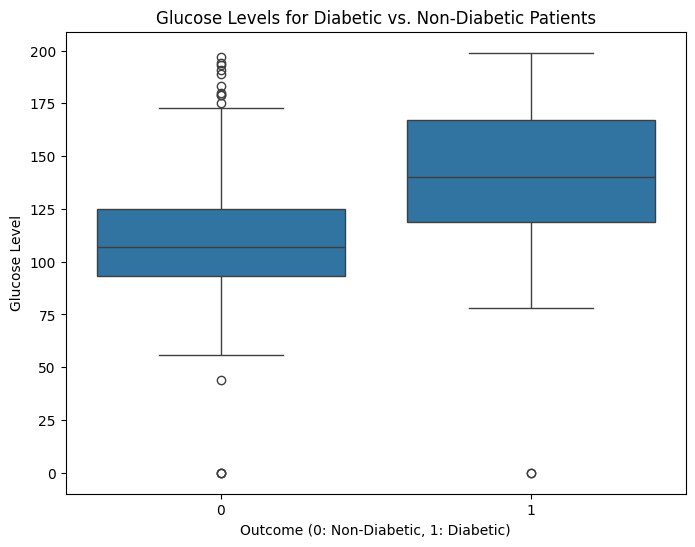

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose Levels for Diabetic vs. Non-Diabetic Patients')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Glucose Level')
plt.show()

In [10]:
#I see some relation by using the average
#go with question 3 :Does BMI play a significant role?
avg_bmi = df.groupby('Outcome')['BMI'].mean()
print(avg_bmi)



Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64


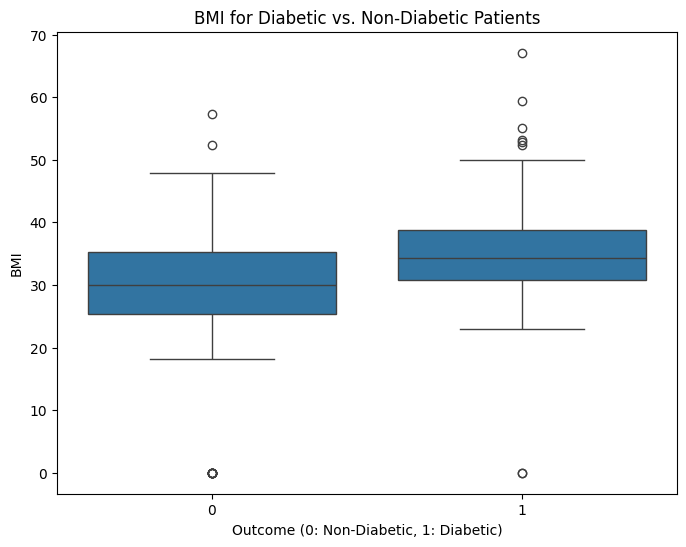

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('BMI for Diabetic vs. Non-Diabetic Patients')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('BMI')
plt.show()

Ok so i think iam done with Phase one with some notes


*   We have 500 non-diabetic and 268 diabetic patients in 768 rows with 9 columns
*   Glucose is a very important feature/predictor
*   BMI is not important as Glucose but it will help



# Phase 2 :Prep Your Data for Prime Time
start to standardizing our features and go on
 our data have no null values so that phase will end by standardizing the data and spliting it

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

X_train shape: (614, 8)
X_test shape: (154, 8)
[[-0.85135507 -0.98013068 -0.40478372 -0.55397256 -0.33131928 -0.60767846
   0.31079384 -0.79216928]
 [ 0.35657564  0.16144422  0.46536842  0.392787   -0.52639809 -0.30213902
  -0.11643851  0.56103382]
 [-0.5493724  -0.50447447 -0.62232176  1.21331196  0.14244354  0.3725939
  -0.76486207 -0.70759409]
 [-0.85135507  0.7956525  -0.73109078 -1.31138021 -0.73076636 -0.28940821
   0.26231357 -0.36929331]
 [-1.15333775 -0.82157861 -0.29601471  1.15019465  0.24462767  1.60748245
  -0.33762972 -0.96131967]]


# Phase 3: Build, Train and Compete!
I will go with 3 type of models


1.   Logistic Regression
2.   Random Forest
3.   SVM

Then I will choose the best of them


In [20]:
#start with the logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log_reg = log_reg.predict(X_test_scaled)

print("Accuracy:", (accuracy_score(y_test, y_pred_log_reg)*100))

Accuracy: 71.42857142857143


In [23]:
#71.43 is not a good accuracy for medicine field , trying to get it up
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(solver='liblinear', random_state=42)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)#I will go with 5 croos validiation
grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("New Accuracy:", accuracy_score(y_test, y_pred_best)*100)


Best parameters found: {'C': 1, 'penalty': 'l1'}
New Accuracy: 71.42857142857143


No higher accuracy achived

In [19]:
#here the random forest go
from sklearn.ensemble import RandomForestClassifier
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(X_train_scaled, y_train)

y_pred_rand_forest = rand_forest.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rand_forest)*100)

Accuracy: 75.97402597402598


In [24]:
#the accuracy gose to about 76% ,i will try to get better
rand_forest = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}


grid_search_rf = GridSearchCV(estimator=rand_forest, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')#3 cross validiation

grid_search_rf.fit(X_train_scaled, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)

best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

print("New Accuracy:", accuracy_score(y_test, y_pred_best_rf)*100)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 100}
New Accuracy: 74.02597402597402


lower accuracy! down to 74 is not a good step to lets continue with another model

In [26]:
#SVM is on the line
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm)*100)


Accuracy: 75.32467532467533


In [30]:
#got a 75.33% , trying to hypernate
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)

grid_search_svm.fit(X_train_scaled, y_train)

print("\nBest parameters for SVM:", grid_search_svm.best_params_)
best_svm_model = grid_search_svm.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test_scaled)
print("New Accuracy:", accuracy_score(y_test, y_pred_best_svm))



Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters for SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
New Accuracy: 0.7207792207792207


After trying all the models and tring to tune it thats what we got


*   Accuracy: 71.43% for the base and hyperprameter linear regression
*   Accuracy: 76% for the hyperprameter Random forest
*   Accuracy: 75.33% for the baseline svm

final score go to the random forest tree model with 76%


# Phase 4: Launch Your Prediction Engine!
I will use random forest for that phase


In [39]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier


champion_model = RandomForestClassifier(random_state=42)
champion_model.fit(X_train_scaled, y_train)

def predict_diabetes(input_data):
    input_data_as_numpy_array = np.asarray(input_data)
    input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)
    scaled_data = scaler.transform(input_data_reshaped)
    prediction = champion_model.predict(scaled_data)

    if prediction[0] == 0:
        return "Non-Diabetic"
    else:
        return "Diabetic"

#here is an example
new_patient_data = (6, 100, 72, 35, 0, 33.6, 0.627, 50)
health_status = predict_diabetes(new_patient_data)

print(f"\nNew patient data: {new_patient_data}")
print(f"Prediction: The patient is likely {health_status}")


New patient data: (6, 100, 72, 35, 0, 33.6, 0.627, 50)
Prediction: The patient is likely Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
